In [ ]:
# ============================================================
# LANGGRAPH MEMORY SKELETON
# ============================================================

from typing import TypedDict

from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.checkpoint.memory import MemorySaver


# ============================================================
# 1. TOOLS
# ============================================================

@tool
def my_tool(a):
    """Description of the tool."""
    pass


tools = [
    my_tool,
]


# ============================================================
# 2. STATE
# ============================================================

class State(TypedDict):
    messages: list


# ============================================================
# 3. MODEL
# ============================================================

llm = ChatOpenAI(
    model="YOUR_MODEL",
    temperature=0
)

llm_with_tools = llm.bind_tools(tools)


# ============================================================
# 4. MODEL NODE
# ============================================================

def chatbot(state: State):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }


# ============================================================
# 5. TOOL NODE
# ============================================================

tool_node = ToolNode(tools)


# ============================================================
# 6. BUILD GRAPH
# ============================================================

builder = StateGraph(State)

builder.add_node("chatbot", chatbot)
builder.add_node("tools", tool_node)

builder.add_edge(START, "chatbot")

builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

builder.add_edge(
    "tools",
    "chatbot"
)


# ============================================================
# 7. MEMORY
# ============================================================

memory = MemorySaver()


# ============================================================
# 8. COMPILE WITH MEMORY
# ============================================================

graph = builder.compile(
    checkpointer=memory
)


# ============================================================
# 9. THREAD / CONVERSATION ID
# ============================================================

config = {
    "configurable": {
        "thread_id": "USER_OR_CONVERSATION_ID"
    }
}


# ============================================================
# 10. INVOKE
# ============================================================

response = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="YOUR USER QUESTION"
            )
        ]
    },
    config=config
)


# ============================================================
# 11. READ RESPONSE
# ============================================================

for message in response["messages"]:

    print(
        type(message).__name__,
        ":",
        message.content
    )

In [4]:
from typing import TypedDict , Annotated

from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph , START , END
from langgraph.graph.message import add_messages

from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

from langchain_openai import ChatOpenAI

@tool
def add(a:int , b:int)->int:
    """Add Two numbers"""
    return a+b

@tool
def substract(a:int , b:int)->int:
    """Subtract Two numbers"""
    return a-b

@tool
def multiply(a:int , b:int)->int:
    """Multiply Two numbers"""
    return a*b

tools=[add,substract,multiply]

class State(TypedDict):
    messages:Annotated[list,add_messages]

llm=ChatOpenAI(
    model="qwen/qwen3-4b-2507",
    base_url="http://127.0.0.1:1234/v1",
    api_key="dummy",
    temperature=0
)

llm_with_tools=llm.bind_tools(tools)


def chatbot(state:State):
    response=llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages":[response]
    }

tool_node=ToolNode(tools)

build=StateGraph(State)

build.add_node("chatbot",chatbot)
build.add_node("tools",tool_node)

build.add_edge(START,'chatbot')

build.add_conditional_edges("chatbot",tools_condition)
build.add_edge("tools","chatbot")

memory=MemorySaver()

graph=build.compile(checkpointer=memory)

config={
    "configurable":{
        "thread_id":"user_1"
    }
}

response=graph.invoke(
    {
        "messages":[
            HumanMessage(
                content="WHat is 12+13?"
            )
        ]
    },
    config=config
)

print("\nFIRST RESPONSE:")
for message in response["messages"]:
    print(type(message).__name__, ":", message.content)

# ============================================================
# 11. SECOND MESSAGE
# ============================================================

response = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="Add that number to 25."
            )
        ]
    },
    config=config
)


print("\nSECOND RESPONSE:")
for message in response["messages"]:
    print(type(message).__name__, ":", message.content)


# ============================================================
# 12. THIRD MESSAGE
# ============================================================

response = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="Now multiply that number by 2."
            )
        ]
    },
    config=config
)


print("\nTHIRD RESPONSE:")
for message in response["messages"]:
    print(type(message).__name__, ":", message.content)

state = graph.get_state(config)

print(state.config)


FIRST RESPONSE:
HumanMessage : WHat is 12+13?
AIMessage : 
ToolMessage : 25
AIMessage : 12 + 13 = 25.

SECOND RESPONSE:
HumanMessage : WHat is 12+13?
AIMessage : 
ToolMessage : 25
AIMessage : 12 + 13 = 25.
HumanMessage : Add that number to 25.
AIMessage : 
ToolMessage : 50
AIMessage : 25 + 25 = 50.

THIRD RESPONSE:
HumanMessage : WHat is 12+13?
AIMessage : 
ToolMessage : 25
AIMessage : 12 + 13 = 25.
HumanMessage : Add that number to 25.
AIMessage : 
ToolMessage : 50
AIMessage : 25 + 25 = 50.
HumanMessage : Now multiply that number by 2.
AIMessage : 
ToolMessage : 100
AIMessage : 50 × 2 = 100.
{'configurable': {'thread_id': 'user_1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a5f8d-53fc-6a53-800d-50161eaaecfd'}}


In [5]:
import os
from typing import List, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain_core.tools import tool
from langchain_core.messages import BaseMessage, SystemMessage
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from docx import Document as WordDocument

# ------------------------------------------------------------
# 1. SETUP & CONFIGURATION
# ------------------------------------------------------------
load_dotenv()

PDF_DIRECTORY = "./PDFS"
CHROMA_DIRECTORY = "./chroma_db"
COLLECTION_NAME = "my_documents"
OUTPUT_DIRECTORY = "./output"

os.makedirs(OUTPUT_DIRECTORY, exist_ok=True)

# ------------------------------------------------------------
# 2. OPTIMIZED EMBEDDINGS & VECTOR STORE (PERSISTENCE CHECK)
# ------------------------------------------------------------
# Specify device if available: e.g., device="cuda" or "mps"
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"} 
)

# Avoid reloading and re-embedding PDFs every time the script runs
if not os.path.exists(CHROMA_DIRECTORY) or not os.listdir(CHROMA_DIRECTORY):
    print("Initializing vector database and indexing PDFs...")
    loader = PyPDFDirectoryLoader(PDF_DIRECTORY)
    documents = loader.load()
    
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150)
    chunks = text_splitter.split_documents(documents)
    
    vector_store = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        collection_name=COLLECTION_NAME,
        persist_directory=CHROMA_DIRECTORY
    )
    print(f"Indexed {len(chunks)} chunks into Chroma DB.")
else:
    print("Loading existing Chroma vector database from disk...")
    vector_store = Chroma(
        collection_name=COLLECTION_NAME,
        embedding_function=embeddings,
        persist_directory=CHROMA_DIRECTORY
    )

retriever = vector_store.as_retriever(search_kwargs={"k": 3}) # Reduced k for speed

# ------------------------------------------------------------
# 3. LLM INITIALIZATION
# ------------------------------------------------------------
llm = ChatOpenAI(
    model="qwen/qwen3-4b-2507",
    base_url="http://127.0.0.1:1234/v1",
    api_key="dummy",
    temperature=0
)

# ------------------------------------------------------------
# 4. TOOLS DEFINITION
# ------------------------------------------------------------
@tool
def search_documents(query: str) -> str:
    """Search the PDF knowledge base for relevant context."""
    docs = retriever.invoke(query)
    if not docs:
        return "No relevant documents found."
    
    return "\n\n".join([
        f"SOURCE: {d.metadata.get('source', 'N/A')} (Page {d.metadata.get('page', 'N/A')})\nCONTENT: {d.page_content}"
        for d in docs
    ])

@tool
def calculator(expression: str) -> str:
    """Calculate mathematical expressions safely."""
    try:
        result = eval(expression, {"__builtins__": {}})
        return str(result)
    except Exception:
        return "Unable to calculate expression."

class ExamQuestion(BaseModel):
    question: str = Field(description="The exam question")
    answer: str = Field(description="Detailed 7-point answer")

class ExamDocumentInput(BaseModel):
    title: str = Field(description="Title of the exam document")
    questions: List[ExamQuestion] = Field(description="List of exam questions and detailed answers")

@tool(args_schema=ExamDocumentInput)
def create_exam_docx(title: str, questions: List[ExamQuestion]) -> str:
    """Creates a Word document containing exam questions and answers directly."""
    try:
        doc = WordDocument()
        doc.add_heading(title, level=0)
        doc.add_paragraph("Exam Preparation Questions and Answers\n")

        for idx, item in enumerate(questions, start=1):
            doc.add_heading(f"Question {idx}: {item.question}", level=2)
            doc.add_heading("Answer", level=3)
            doc.add_paragraph(item.answer)
            doc.add_paragraph("-" * 50)

        file_path = os.path.join(OUTPUT_DIRECTORY, "exam_questions1.docx")
        doc.save(file_path)
        return f"Document created successfully at: {file_path}"
    except Exception as e:
        return f"Failed to create document: {str(e)}"

tools = [search_documents, calculator, create_exam_docx]
llm_with_tools = llm.bind_tools(tools)

# ------------------------------------------------------------
# 5. STREAMLINED SYSTEM PROMPT
# ------------------------------------------------------------
SYSTEM_PROMPT = """You are an Agentic RAG assistant.

EFFICENCY RULES:
1. When asked to retrieve data, call `search_documents`.
2. When asked to generate exam questions and save them to a file, compile the results and IMMEDIATELY call `create_exam_docx` with the argument structure. DO NOT print out all questions and answers into the chat prior to invoking the tool. Call the tool directly to prevent double-generation.
3. Keep initial responses concise and ground answers strictly in retrieved PDF context.
"""

# ------------------------------------------------------------
# 6. LANGGRAPH ORCHESTRATION
# ------------------------------------------------------------
class AgentState(BaseModel):
    messages: Annotated[List[BaseMessage], add_messages]

def agent(state: AgentState):
    messages = [SystemMessage(content=SYSTEM_PROMPT), *state.messages]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

builder = StateGraph(AgentState)
builder.add_node("agent", agent)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)
builder.add_edge("tools", "agent")

graph = builder.compile()

# ------------------------------------------------------------
# 7. EXECUTION
# ------------------------------------------------------------
question = """
Analyze the PDF documents.
Create 10 important exam questions about AI in games.
For every question, provide a detailed answer with 7 points.
Then create a Word document containing all questions followed by their answers.
"""

result = graph.invoke({"messages": [{"role": "user", "content": question}]})

for message in result["messages"]:
    print(f"\n[{type(message).__name__}]")
    if message.content:
        print(message.content)
    if hasattr(message, "tool_calls") and message.tool_calls:
        for tool_call in message.tool_calls:
            print(f"  Called Tool: {tool_call['name']}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading existing Chroma vector database from disk...

[HumanMessage]

Analyze the PDF documents.
Create 10 important exam questions about AI in games.
For every question, provide a detailed answer with 7 points.
Then create a Word document containing all questions followed by their answers.


[AIMessage]
  Called Tool: search_documents

[ToolMessage]
SOURCE: PDFS\Evolution_of_Video_Games_and_AI.pdf (Page 0)
CONTENT: The Evolution of Video Games and Artificial
 Intelligence
 Informative Overview
Introduction
Video games have evolved from simple electronic experiments into a major form of interactive
media. Early games were constrained by limited memory, processing power, storage, graphics
hardware, and input devices. Modern games can simulate large worlds, render complex scenes in
real time, connect millions of players, and support sophisticated physical and behavioral systems.
Artificial intelligence has played an important role in this evolution, particularly in controlling
non-player

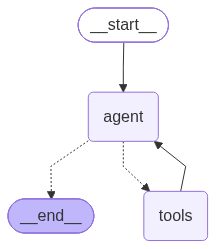

In [5]:
from IPython.display import Image , display
display(Image(graph.get_graph().draw_mermaid_png()))